In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

da = pd.read_excel('../../utaut2_dataset/utaut2_subsample.xlsx')

construct_names = {
    'PU': 'Воспринимаемая полезность',
    'PEOU': 'Лёгкость использования',
    'SI': 'Социальное влияние',
    'FC': 'Поддерживающие условия',
    'HM': 'Гедоническая мотивация',
    'PV': 'Ценность цены',
    'HAB': 'Привычка',
    'BI': 'Поведенческое намерение'
}

constructs = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB', 'BI']
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

# Пункты конструктов (нужны для Cronbach alpha)
df_full = pd.read_excel('../../utaut2_dataset/new_result.xlsx')
cols = df_full.columns.tolist()
construct_items = {
    'PU':   cols[13:16],
    'PEOU': cols[16:19],
    'SI':   cols[19:22],
    'FC':   cols[22:25],
    'HM':   cols[25:28],
    'PV':   cols[28:31],
    'HAB':  cols[31:34],
    'BI':   cols[34:37],
}

print(f'Аналитическая подвыборка UTAUT2: {len(da)}')

Аналитическая подвыборка UTAUT2: 164


In [2]:
utaut_desc = da[constructs].agg(['mean', 'std', 'min', 'median', 'max']).T.round(2)
utaut_desc.columns = ['Среднее', 'SD', 'Мин', 'Медиана', 'Макс']
utaut_desc['Конструкт'] = [construct_names[c] for c in utaut_desc.index]
utaut_desc = utaut_desc[['Конструкт', 'Среднее', 'SD', 'Мин', 'Медиана', 'Макс']]

utaut_desc

,Конструкт,Среднее,SD,Мин,Медиана,Макс
PU,Воспринимаемая полезность,3.65,0.64,1.67,3.67,5.0
PEOU,Лёгкость использования,3.95,0.49,2.33,4.00,5.0
SI,Социальное влияние,3.65,0.61,1.00,3.67,5.0
FC,Поддерживающие условия,4.16,0.38,3.00,4.33,5.0
HM,Гедоническая мотивация,3.82,0.51,1.67,4.00,5.0
PV,Ценность цены,3.28,0.66,2.00,3.33,5.0
HAB,Привычка,3.01,1.21,1.00,3.00,5.0
BI,Поведенческое намерение,3.71,0.68,1.67,3.67,5.0


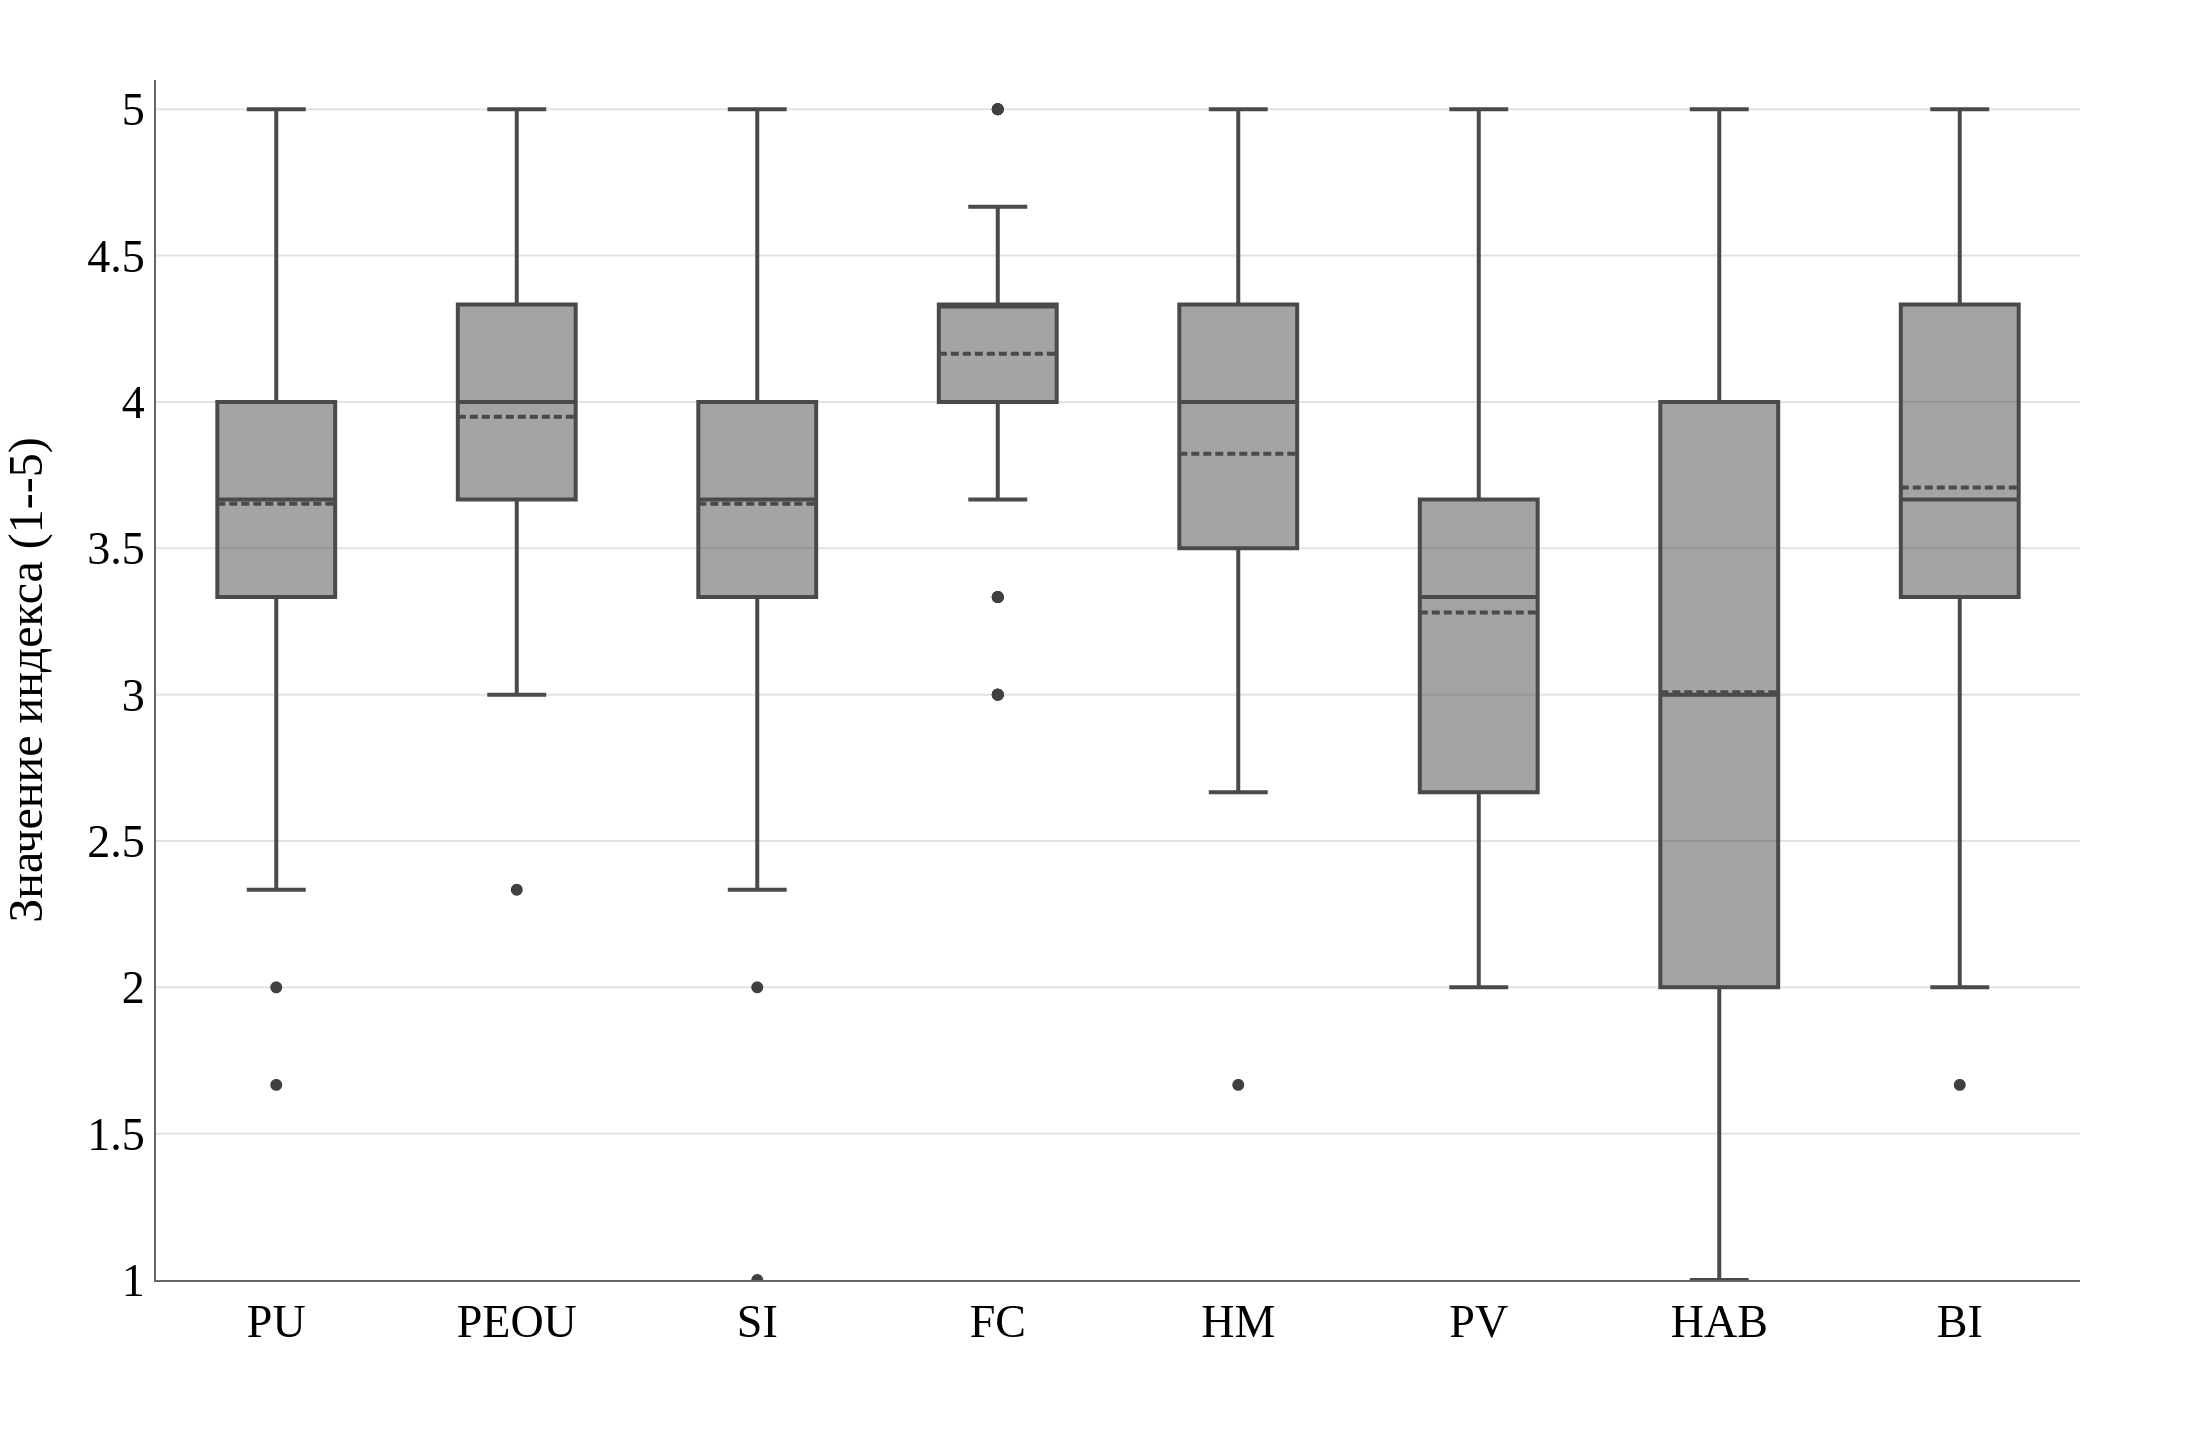

In [3]:
fig = go.Figure()

for c in constructs:
    fig.add_trace(go.Box(
        y=da[c],
        name=c,
        marker_color=PRIMARY,
        line_color=PRIMARY_DARK,
        boxmean=True
    ))

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    yaxis=dict(
        title=dict(text='Значение индекса (1--5)', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[1, 5.1]
    ),
    margin=dict(l=70, r=60, t=40, b=80),
    width=1100,
    height=720
)

fig.show()